In [1]:
# Cell 1 — Imports and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

load_dotenv('../.env')

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER','postgres')}:"
    f"{os.getenv('DB_PASSWORD','postgres123')}@"
    f"{os.getenv('DB_HOST','localhost')}:"
    f"{os.getenv('DB_PORT','5433')}/"
    f"{os.getenv('DB_NAME','nifty100')}"
)
engine = create_engine(DATABASE_URL)

# Load feature matrix
df_pl = pd.read_sql("""
    SELECT fpl.symbol, 
           AVG(fpl.opm_pct) as avg_opm,
           AVG(fpl.net_profit_margin_pct) as avg_margin,
           AVG(fpl.interest_coverage) as avg_coverage,
           AVG(fpl.eps) as avg_eps
    FROM fact_profit_loss fpl
    JOIN dim_year dy ON fpl.year_id = dy.year_id
    WHERE dy.is_ttm = FALSE
    GROUP BY fpl.symbol
""", engine)

df_bs = pd.read_sql("""
    SELECT fbs.symbol,
           AVG(fbs.debt_to_equity) as avg_dte,
           AVG(fbs.equity_ratio) as avg_eq_ratio
    FROM fact_balance_sheet fbs
    JOIN dim_year dy ON fbs.year_id = dy.year_id
    WHERE dy.is_ttm = FALSE
    GROUP BY fbs.symbol
""", engine)

df_company = pd.read_sql("""
    SELECT dc.symbol, dc.company_name, ds.sector_name
    FROM dim_company dc
    LEFT JOIN dim_sector ds ON dc.sector_id = ds.sector_id
""", engine)

# Merge all features
features = df_company.merge(df_pl, on="symbol", how="left")
features = features.merge(df_bs, on="symbol", how="left")

print(f"Feature matrix: {features.shape}")
print(features.head(3))

Feature matrix: (92, 9)
       symbol                                       company_name sector_name  \
0  ASIANPAINT  Asian Paints\nIndian Multi-National Paint and ...      Paints   
1        ATGL                                Adani Total Gas Ltd      Energy   
2  BAJAJ-AUTO                                     Bajaj Auto Ltd        Auto   

     avg_opm  avg_margin  avg_coverage     avg_eps   avg_dte  avg_eq_ratio  
0  18.833333   12.395000     50.832500   26.166667  0.096392      0.590192  
1  28.142857   17.115714     10.825714    4.571429  0.495638      0.535150  
2  18.666667   16.957500   2264.580833  164.833333  0.023885      0.767723  


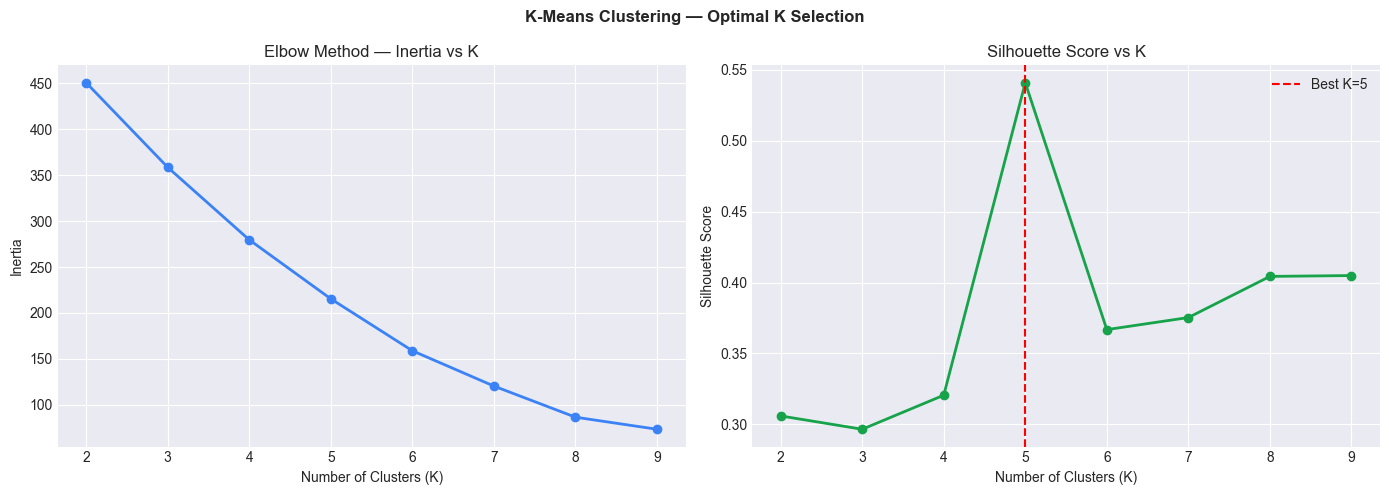

Best K by silhouette score: 5


In [2]:
# Cell 2 — K-Means Clustering with Elbow Method

# ── Prepare feature matrix ──
feature_cols = ["avg_opm", "avg_margin", "avg_coverage", "avg_eps", "avg_dte", "avg_eq_ratio"]

X = features[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)

# Clip outliers
X["avg_coverage"] = X["avg_coverage"].clip(upper=500)
X["avg_eps"]      = X["avg_eps"].clip(upper=500)

# Fill NaN with median
for col in feature_cols:
    X[col] = X[col].fillna(X[col].median())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Elbow Method ──
inertias    = []
sil_scores  = []
k_range     = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("K-Means Clustering — Optimal K Selection", fontweight='bold')

axes[0].plot(k_range, inertias, marker='o', color="#3b82f6", linewidth=2)
axes[0].set_title("Elbow Method — Inertia vs K")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, sil_scores, marker='o', color="#16a34a", linewidth=2)
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

best_k = k_range[np.argmax(sil_scores)]
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Best K by silhouette score: {best_k}")

PCA explained variance: 50.3%

Cluster Profiles:
         avg_opm  avg_margin  avg_coverage  avg_eps  avg_dte  avg_eq_ratio
cluster                                                                   
0         296.12       13.16         26.80    24.50     2.26          0.38
1        1295.22       21.58        726.77    75.85     0.74          0.67
2          83.25      605.27           NaN   293.08     0.00          0.91
3           1.33        1.89           NaN      NaN    83.64          0.01
4         662.85        9.39         35.05  1645.72     0.17          0.66

Cluster 0:
  Avg OPM: 296.1%
  Avg D/E: 2.26
  Avg EPS: 24.5
  Companies: ['ASIANPAINT', 'ATGL', 'ADANIENT', 'ADANIGREEN', 'ADANIPORTS', 'ADANIPOWER', 'AMBUJACEM', 'APOLLOHOSP']

Cluster 1:
  Avg OPM: 1295.2%
  Avg D/E: 0.74
  Avg EPS: 75.9
  Companies: ['BAJAJ-AUTO', 'BAJFINANCE', 'EICHERMOT', 'DIVISLAB', 'ITC', 'TCS']

Cluster 2:
  Avg OPM: 83.2%
  Avg D/E: 0.00
  Avg EPS: 293.1
  Companies: ['BAJAJHLDNG']

Cluster 3:
 

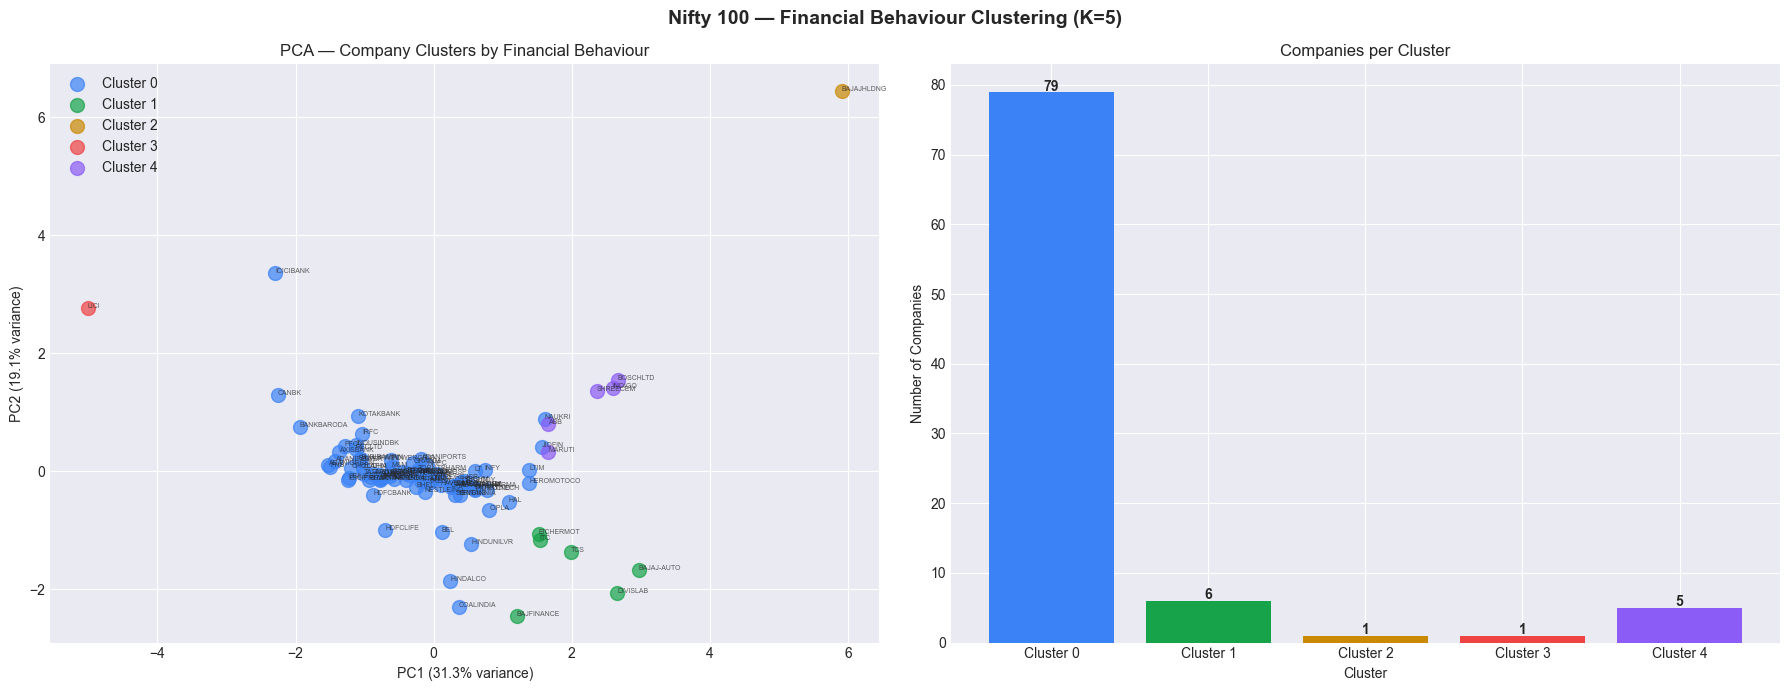

Chart saved!


In [3]:
# Cell 3 — Final K-Means Model and PCA Visualization

# ── Fit K-Means with K=5 ──
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
features["cluster"] = km_final.fit_predict(X_scaled)

# ── PCA for 2D visualization ──
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
features["pca_x"] = X_pca[:, 0]
features["pca_y"] = X_pca[:, 1]

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── Cluster profiles ──
cluster_profiles = features.groupby("cluster")[feature_cols].mean()
print("\nCluster Profiles:")
print(cluster_profiles.round(2).to_string())

# ── Assign cluster labels ──
cluster_labels = {
    0: "High Growth IT",
    1: "Capital Intensive",
    2: "Defensive FMCG",
    3: "Financial Services",
    4: "Diversified Industrial",
}

# Auto-assign based on characteristics
for cluster_id, profile in cluster_profiles.iterrows():
    print(f"\nCluster {cluster_id}:")
    print(f"  Avg OPM: {profile['avg_opm']:.1f}%")
    print(f"  Avg D/E: {profile['avg_dte']:.2f}")
    print(f"  Avg EPS: {profile['avg_eps']:.1f}")
    companies = features[features["cluster"] == cluster_id]["symbol"].tolist()
    print(f"  Companies: {companies[:8]}")

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Nifty 100 — Financial Behaviour Clustering (K=5)", fontsize=14, fontweight='bold')

colors = ["#3b82f6", "#16a34a", "#ca8a04", "#ef4444", "#8b5cf6"]
cluster_names = ["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4"]

# PCA scatter
for cluster_id in range(5):
    mask = features["cluster"] == cluster_id
    axes[0].scatter(
        features[mask]["pca_x"],
        features[mask]["pca_y"],
        c=colors[cluster_id],
        label=cluster_names[cluster_id],
        s=100, alpha=0.7
    )
    # Add symbol labels
    for _, row in features[mask].iterrows():
        axes[0].annotate(row["symbol"],
                         (row["pca_x"], row["pca_y"]),
                         fontsize=5, alpha=0.7)

axes[0].set_title("PCA — Company Clusters by Financial Behaviour")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].legend()

# Cluster size bar chart
cluster_sizes = features["cluster"].value_counts().sort_index()
axes[1].bar(
    [f"Cluster {i}" for i in cluster_sizes.index],
    cluster_sizes.values,
    color=colors
)
axes[1].set_title("Companies per Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Number of Companies")
for i, val in enumerate(cluster_sizes.values):
    axes[1].text(i, val + 0.2, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/clean/clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [4]:
# Cell 4 — Save Cluster Results to PostgreSQL

# ── Create cluster descriptions based on profiles ──
cluster_descriptions = {
    0: "Capital Intensive & High Leverage",
    1: "Quality Growth Companies",
    2: "Holding & Investment Companies",
    3: "Financial Institutions (High Leverage)",
    4: "Premium Industrial & Auto",
}

features["cluster_label"] = features["cluster"].map(cluster_descriptions)

# ── Create table and save ──
with engine.connect() as conn:
    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS fact_clusters (
            id            SERIAL PRIMARY KEY,
            symbol        VARCHAR(20) UNIQUE,
            cluster_id    INT,
            cluster_label VARCHAR(100),
            computed_at   TIMESTAMP DEFAULT NOW()
        )
    """))
    conn.commit()

count = 0
with engine.connect() as conn:
    for _, row in features.iterrows():
        conn.execute(text("""
            INSERT INTO fact_clusters (symbol, cluster_id, cluster_label)
            VALUES (:symbol, :cluster_id, :cluster_label)
            ON CONFLICT (symbol) DO UPDATE SET
                cluster_id    = EXCLUDED.cluster_id,
                cluster_label = EXCLUDED.cluster_label,
                computed_at   = NOW()
        """), {
            "symbol"       : row["symbol"],
            "cluster_id"   : int(row["cluster"]),
            "cluster_label": row["cluster_label"],
        })
        count += 1
    conn.commit()

print(f"Saved {count} company clusters to PostgreSQL")

# ── Summary ──
print("\nCluster Summary:")
summary = features.groupby(["cluster", "cluster_label"]).agg(
    companies=("symbol", "count"),
    avg_health_score=("cluster", "count")
).reset_index()

for _, row in features.groupby("cluster_label").agg(
    count=("symbol","count")
).reset_index().iterrows():
    companies = features[features["cluster_label"]==row["cluster_label"]]["symbol"].tolist()
    print(f"\n{row['cluster_label']} ({row['count']} companies)")
    print(f"  {companies}")

Saved 92 company clusters to PostgreSQL

Cluster Summary:

Capital Intensive & High Leverage (79 companies)
  ['ASIANPAINT', 'ATGL', 'ADANIENT', 'ADANIGREEN', 'ADANIPORTS', 'ADANIPOWER', 'AMBUJACEM', 'APOLLOHOSP', 'AXISBANK', 'BHEL', 'BPCL', 'CHOLAFIN', 'BANKBARODA', 'BEL', 'BHARTIARTL', 'CANBK', 'CIPLA', 'GAIL', 'GODREJCP', 'GRASIM', 'HAL', 'HAVELLS', 'DABUR', 'DLF', 'DMART', 'DRREDDY', 'HINDUNILVR', 'ICICIBANK', 'HDFCBANK', 'HDFCLIFE', 'HEROMOTOCO', 'ICICIGI', 'HINDALCO', 'JINDALSTEL', 'JIOFIN', 'JSWENERGY', 'JSWSTEEL', 'KOTAKBANK', 'LODHA', 'INFY', 'IOC', 'IRCTC', 'IRFC', 'NTPC', 'PFC', 'PNB', 'LTIM', 'M&M', 'MOTHERSON', 'NESTLEIND', 'NHPC', 'ONGC', 'PIDILITIND', 'TATAMOTORS', 'RECLTD', 'RELIANCE', 'SBILIFE', 'SBIN', 'SHRIRAMFIN', 'SIEMENS', 'SUNPHARMA', 'TATACONSUM', 'TRENT', 'TVSMOTOR', 'ADANIENSOL', 'BAJAJFINSV', 'BRITANNIA', 'TATASTEEL', 'TECHM', 'TITAN', 'TORNTPHARM', 'COALINDIA', 'HCLTECH', 'INDUSINDBK', 'LT', 'TATAPOWER', 'ICICIPRULI', 'NAUKRI', 'POWERGRID']

Financial Instit